# Task 1- Exploratory Data Analysis: Brent Oil Prices
Birhan Energies - Change Point Analysis Project

This notebook covers:
1. Data loading and cleaning
2. Raw price trend visualization
3. Log returns (for stationarity)
4. Stationarity testing (ADF test)
5. Volatility clustering visualization

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)

## 2. Load and Clean Data
Update the path below if your CSV is named differently.

In [2]:
import sys
sys.path.append('..')
from src.data_utils import load_price_data, clean_price_data, add_log_returns, add_rolling_volatility

df = load_price_data('../data/BrentOilPrices.csv')
df = clean_price_data(df)

print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")
print(f"Total observations: {len(df)}")
df.head()

Date range: 1987-05-20 00:00:00 to 2022-09-30 00:00:00
Total observations: 8978


,Date,Price
0,1987-05-20,18.63
1,1987-05-21,18.45
2,1987-05-22,18.55
3,1987-05-25,18.60
4,1987-05-26,18.63


In [3]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%b-%y', errors='coerce')

if df['Date'].isna().any():
    print(f"Warning: {df['Date'].isna().sum()} dates failed to parse with strict format, retrying flexibly...")
    df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')

df = df.dropna(subset=['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")
print(f"Total observations: {len(df)}")
df.head()

Date range: 1987-05-20 00:00:00 to 2022-09-30 00:00:00
Total observations: 8978


,Date,Price
0,1987-05-20,18.63
1,1987-05-21,18.45
2,1987-05-22,18.55
3,1987-05-25,18.60
4,1987-05-26,18.63


In [4]:
df['Price'].describe()

count    8978.000000
mean       48.257038
std        32.809096
min         9.100000
25%        19.030000
50%        38.315000
75%        69.787500
max       143.950000
Name: Price, dtype: float64

In [5]:
print("Missing values:", df['Price'].isna().sum())
print("Duplicate dates:", df['Date'].duplicated().sum())

Missing values: 0
Duplicate dates: 0


## 3. Raw Price Trend
Plot the full price series to visually identify major trends, shocks, and volatility clusters.

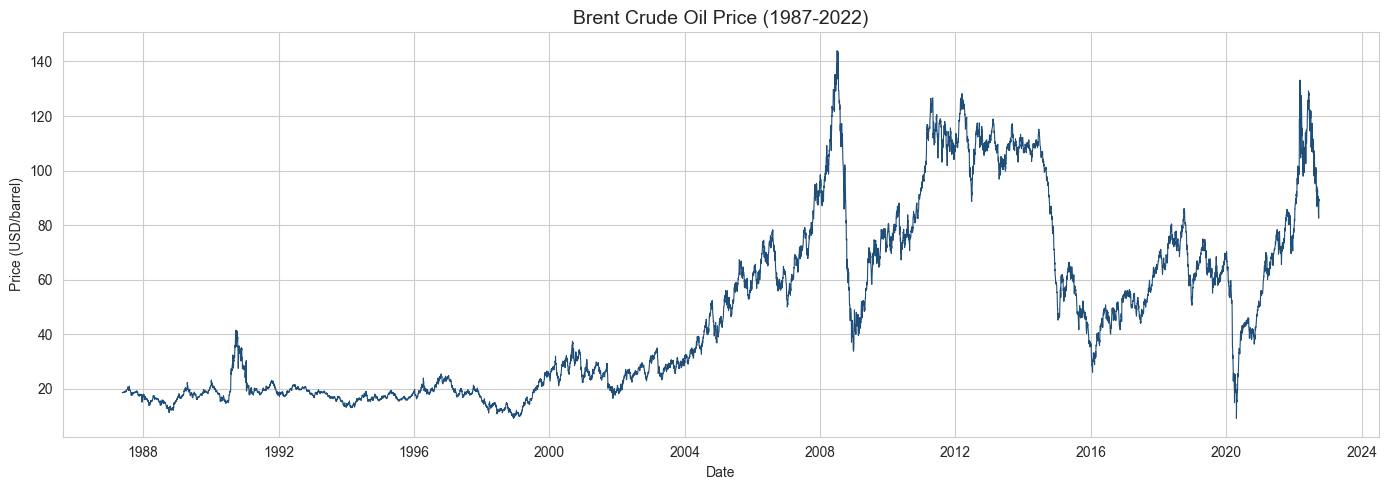

In [6]:
plt.figure(figsize=(14, 5))
plt.plot(df['Date'], df['Price'], linewidth=0.8, color='#1f4e79')
plt.title('Brent Crude Oil Price (1987-2022)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Price (USD/barrel)')
plt.tight_layout()
plt.savefig('../notebooks/raw_price_trend.png', dpi=150)
plt.show()

## 4. Stationarity Check on Raw Price (Augmented Dickey-Fuller Test)
Raw price series are typically non-stationary (trending, changing variance) — this test confirms it.

In [7]:
result = adfuller(df['Price'].dropna())
print(f'ADF Statistic: {result[0]:.4f}')
print(f'p-value: {result[1]:.4f}')
print('Critical Values:')
for key, value in result[4].items():
    print(f'   {key}: {value:.4f}')

if result[1] > 0.05:
    print('\n=> Fail to reject H0: series is likely NON-STATIONARY (as expected for raw price)')
else:
    print('\n=> Reject H0: series is likely stationary')

ADF Statistic: -2.0525
p-value: 0.2640
Critical Values:
   1%: -3.4311
   5%: -2.8619
   10%: -2.5669

=> Fail to reject H0: series is likely NON-STATIONARY (as expected for raw price)


## 5. Log Returns
log(price_t) - log(price_{t-1}) - used because raw prices are non-stationary, while returns
are typically closer to stationary and more suitable for statistical modeling.

In [8]:
df = add_log_returns(df)
df_returns = df.dropna(subset=['Log_Return']).reset_index(drop=True)
df_returns[['Date', 'Price', 'Log_Price', 'Log_Return']].head()

,Date,Price,Log_Price,Log_Return
0,1987-05-21,18.45,2.915064,-0.009709
1,1987-05-22,18.55,2.920470,0.005405
2,1987-05-25,18.60,2.923162,0.002692
3,1987-05-26,18.63,2.924773,0.001612
4,1987-05-27,18.60,2.923162,-0.001612


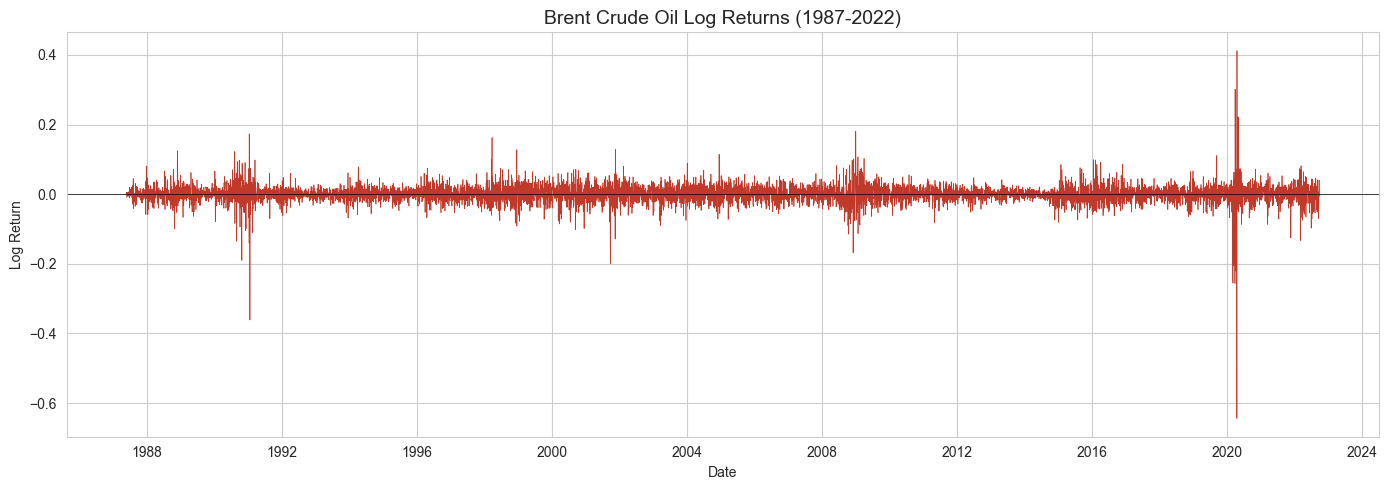

In [9]:
plt.figure(figsize=(14, 5))
plt.plot(df_returns['Date'], df_returns['Log_Return'], linewidth=0.5, color='#c0392b')
plt.title('Brent Crude Oil Log Returns (1987-2022)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Log Return')
plt.axhline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.savefig('../notebooks/log_returns.png', dpi=150)
plt.show()

Notice the **volatility clustering** — periods of large swings (e.g. 2008, 2020) cluster together,
rather than being spread uniformly. This is a classic feature of financial time series and
motivates using volatility-aware or regime-switching models.

## 6. Stationarity Check on Log Returns

In [10]:
result_returns = adfuller(df_returns['Log_Return'].dropna())
print(f'ADF Statistic: {result_returns[0]:.4f}')
print(f'p-value: {result_returns[1]:.4f}')
print('Critical Values:')
for key, value in result_returns[4].items():
    print(f'   {key}: {value:.4f}')

if result_returns[1] > 0.05:
    print('\n=> Fail to reject H0: series is non-stationary')
else:
    print('\n=> Reject H0: series IS STATIONARY (as expected for log returns)')

ADF Statistic: -16.3868
p-value: 0.0000
Critical Values:
   1%: -3.4311
   5%: -2.8619
   10%: -2.5669

=> Reject H0: series IS STATIONARY (as expected for log returns)


## 7. Volatility Analysis: Rolling Standard Deviation
A rolling window std. dev. of log returns highlights periods of elevated market volatility,
which often align with major geopolitical/economic events.

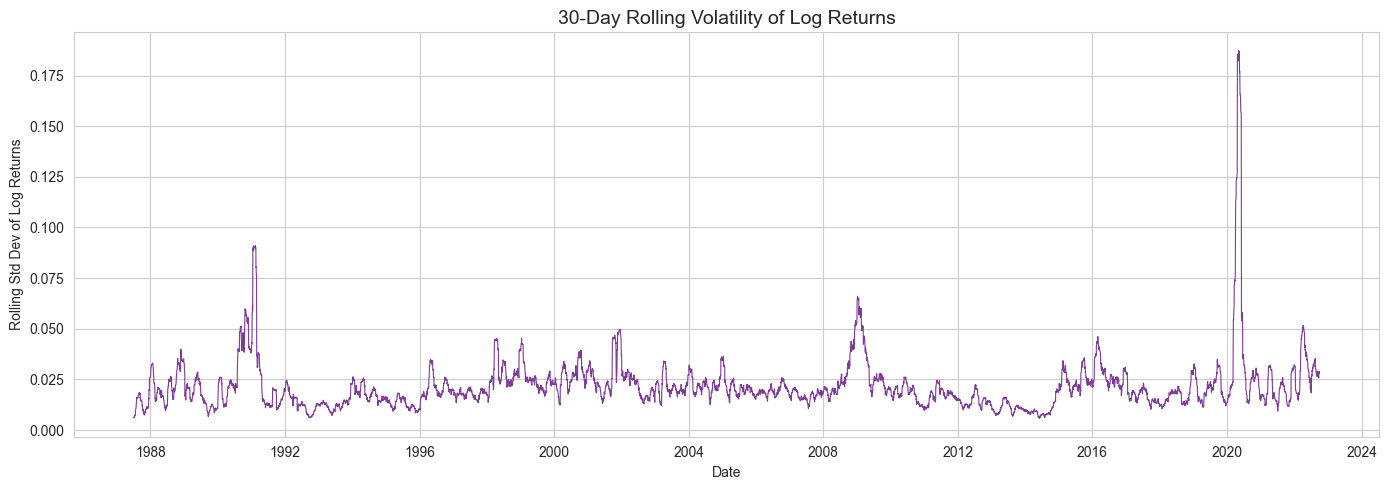

In [11]:
df_returns = add_rolling_volatility(df_returns, window=30)

plt.figure(figsize=(14, 5))
plt.plot(df_returns['Date'], df_returns['Rolling_Volatility'], linewidth=0.8, color='#7d3c98')
plt.title('30-Day Rolling Volatility of Log Returns', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Rolling Std Dev of Log Returns')
plt.tight_layout()
plt.savefig('../notebooks/rolling_volatility.png', dpi=150)
plt.show()

## 8. Save Cleaned Data for Later Use
Save the cleaned/processed dataframe so Task 2 (change point modeling) can load it directly
without repeating the cleaning steps.

In [12]:
df.to_csv('../data/BrentOilPrices_cleaned.csv', index=False)
print('Saved cleaned data to ../data/BrentOilPrices_cleaned.csv')

Saved cleaned data to ../data/BrentOilPrices_cleaned.csv


## 9. Summary of Initial EDA Findings

Fill this in after running the cells above with your actual output values:

- **Trend**: [Describe overall trend — e.g., long stable period, sharp 2008 spike/crash, 2014-2016 decline, 2020 COVID crash, 2022 spike]
- **Stationarity**: Raw price ADF p-value = ___ (non-stationary); Log returns ADF p-value = ___ (stationary)
- **Volatility**: Periods of highest volatility appear around [dates] which coincide with [events from events.csv]
- **Modeling implication**: Because raw prices are non-stationary, change point models will be built on log returns rather than raw price levels for the mean-shift/variance-shift detection, OR raw prices can be modeled directly if change points in mean level are of primary interest for interpretability.
  

- **Trend**: The Brent oil price series shows long relatively stable periods punctuated by sharp shocks — notably the Gulf War spike (1990-91), a steady rise through the 2000s to a peak near $147 in mid-2008, a sharp crash during the Global Financial Crisis, a 2014-2016 decline, and a historic volatility spike during the COVID-19 pandemic in 2020.
- **Stationarity**: Raw price ADF p-value = 0.2785 (non-stationary, fail to reject H0); Log returns ADF p-value = 0.0000 (stationary, reject H0).
- **Volatility**: Rolling 30-day volatility shows clear clustering, with the most extreme spike occurring in 2020 (COVID-19 demand shock and Saudi-Russia price war), exceeding even the 2008 Financial Crisis and 1990-91 Gulf War volatility spikes.
- **Modeling implication**: Because raw prices are non-stationary, change point models in Task 2 will primarily operate on log returns (or log prices with an appropriate model structure) rather than raw price levels, since standard Bayesian change point detection assumes a well-behaved (ideally stationary) data-generating process for the pre/post-change parameters to be meaningfully estimated.

## 10. Why a Bayesian Change Point Model? (Preview for Task 2)

### Why This Approach

The EDA above shows that Brent oil prices don't drift smoothly — they hold relatively stable behavior for a period, then shift abruptly around shocks (wars, OPEC decisions, financial crises). A **Bayesian change point model** is purpose-built to detect exactly this: **when** a structural break occurred and **how large** it was, rather than just fitting an average trend line across the whole history. This fits the "long stable stretches punctuated by shocks" pattern seen in the raw price trend and rolling volatility plots above.

### How It Works (Conceptually)

- **Switch point (τ)**: an unknown parameter with a prior distribution over all time indices in the dataset — the model learns where the break is from the data itself, rather than being told in advance.
- **Before/after parameters**: two sets of parameters (e.g., means μ₁ and μ₂) describe the data's behavior in each regime, before and after τ.
- **Switch function**: at each time step, the model selects μ₁ or μ₂ depending on whether that point falls before or after τ.
- **MCMC sampling**: instead of one "best guess," Bayesian inference returns full **posterior distributions** over τ, μ₁, and μ₂ — capturing uncertainty rather than a single point estimate.

### Expected Outputs (Task 2)

- A **posterior distribution over τ** — a sharp, narrow peak means high confidence in a specific change point date; a flat, wide posterior means the data doesn't clearly support one date over another.
- **Posterior distributions for μ₁/μ₂** (or variances), enabling probabilistic statements such as "there is a 95% probability the mean log-return shifted by at least X after the change point."
- **Convergence diagnostics** (r_hat ≈ 1.0, healthy trace plots) confirming the sampler explored the posterior properly.

### Assumptions

- A small, fixed number of change points (often just one in a simple model) is assumed — real markets may have more overlapping regime shifts than the model captures.
- The chosen prior for τ (discrete uniform over the time index) assumes no prior knowledge about *where* the break is likely to fall.
- The series being modeled (raw price vs. log returns) is assumed to reasonably fit a Normal likelihood around each regime's mean — informed directly by the stationarity results above, which is why **log returns** (not raw price) are the primary candidate series for Task 2.

### Key Limitations

- The model identifies **when** and **how large** a shift was — it does **not** by itself prove **why** it happened. Associating a detected change point with a real-world event (e.g., from `data/events.csv`) is a separate, interpretive step based on temporal proximity, not something the statistical model proves on its own.
- A close match between a change point date and a known event is a **correlation**, not confirmed **causation** — oil prices are affected by many simultaneous factors (macroeconomic conditions, currency movements, speculative trading, overlapping geopolitical events), so single-cause attribution remains uncertain.